# Lab 3: Contextual Bandit-Based News Article Recommendation System

**Course:** Reinforcement Learning Fundamentals  
**Student Name:** Niyati Singh 
**Roll Number:** U20230080 
**GitHub Branch:** niyati_u20230080

**Objective:** To implement a News Recommendation System using Contextual Multi-Armed Bandits (CMAB) to recommend news articles based on user categories.

## Imports and Setup

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from rlcmab_sampler import sampler

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


ROLL_NUMBER = 80  
print(f"Roll Number: {ROLL_NUMBER}")

Roll Number: 80


## Load Datasets

In [19]:
# Load datasets
news_df = pd.read_csv("data/news_articles.csv")
train_users = pd.read_csv("data/train_users.csv")
test_users = pd.read_csv("data/test_users.csv")

print(f"\nDataset Shapes:")
print(f"  • News articles: {news_df.shape}")
print(f"  • Training users: {train_users.shape}")
print(f"  • Test users: {test_users.shape}")


Dataset Shapes:
  • News articles: (209527, 6)
  • Training users: (2000, 33)
  • Test users: (2000, 32)


In [20]:
# Quick data inspection
print(f"\nNews Categories ({len(news_df['category'].unique())} total):")
print(news_df['category'].value_counts().head(10))

print(f"\nUser Label Distribution:")
print(train_users['label'].value_counts())


News Categories (42 total):
category
POLITICS          35602
WELLNESS          17945
ENTERTAINMENT     17362
TRAVEL             9900
STYLE & BEAUTY     9814
PARENTING          8791
HEALTHY LIVING     6694
QUEER VOICES       6347
FOOD & DRINK       6340
BUSINESS           5992
Name: count, dtype: int64

User Label Distribution:
label
user_2    712
user_1    707
user_3    581
Name: count, dtype: int64


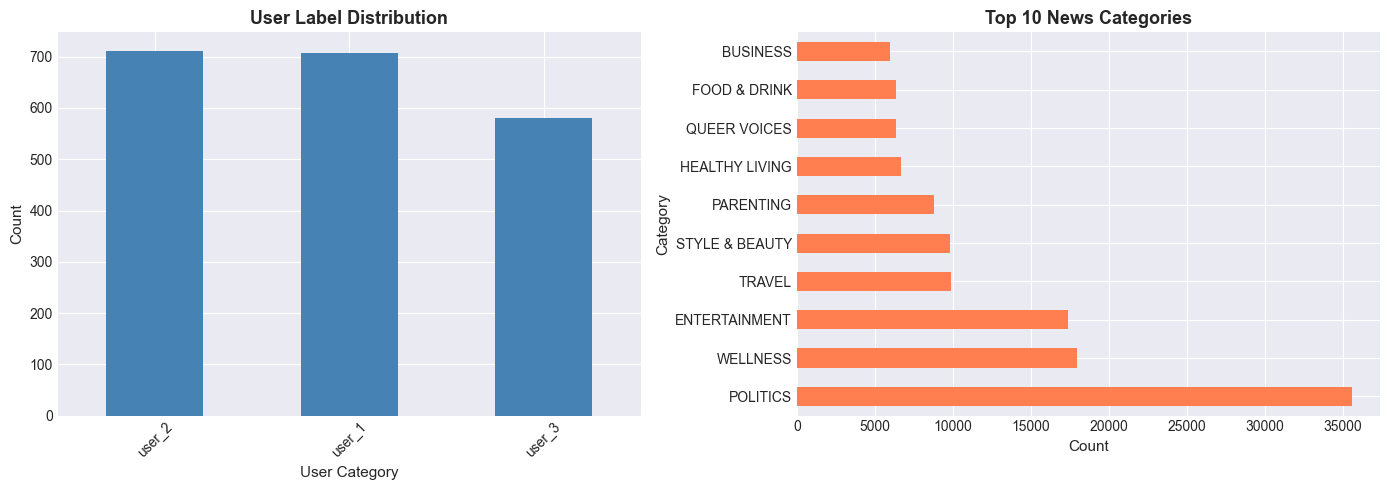

In [21]:
#Visualizing label distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#User label distribution
train_users['label'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('User Label Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('User Category', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].tick_params(axis='x', rotation=45)

#News category distribution
news_df['category'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Top 10 News Categories', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Count', fontsize=11)
axes[1].set_ylabel('Category', fontsize=11)

plt.tight_layout()
plt.show()

In [23]:
#Checking for missing values
print("\nMissing Values Analysis:")
print(f"Training Users - Missing: {train_users.isnull().sum().sum()} values")
print(f"Test Users - Missing: {test_users.isnull().sum().sum()} values")
print(f"News Articles - Missing: {news_df.isnull().sum().sum()} values")


Missing Values Analysis:
Training Users - Missing: 698 values
Test Users - Missing: 679 values
News Articles - Missing: 57136 values


## 5.1 Data Pre-processing

In this section we:
- Handle missing values  
- Filter news articles for relevant categories (Entertainment, Education, Tech, Crime)  
- Encode categorical features  
- Prepare data for user classification

In [27]:
#Filtering Articles for target categories
target_categories = ['ENTERTAINMENT', 'EDUCATION', 'TECH', 'CRIME']
news_df_filtered = news_df[news_df['category'].isin(target_categories)].copy()
news_df_filtered.reset_index(drop=True, inplace=True)

print(f"\nFiltered Articles: {news_df_filtered.shape[0]} articles")
print(f"\nCategory Distribution:")
for cat in target_categories:
    count = (news_df_filtered['category'] == cat).sum()
    print(f"  • {cat}: {count} articles")

#User Preprocessing
def preprocess_users(df, is_training=True):
    """Enhanced preprocessing with multiple strategies"""
    df_clean = df.copy()
    
    #Standardize labels
    if 'label' in df_clean.columns:
        df_clean['label'] = df_clean['label'].str.replace('user_', 'User', regex=False).str.capitalize()
    
    #Identify numeric and categorical columns
    numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    if 'label' in numeric_cols:
        numeric_cols.remove('label')
    
    #Handle missing values with mean imputation
    for col in numeric_cols:
        if df_clean[col].isnull().any():
            df_clean[col].fillna(df_clean[col].mean(), inplace=True)
    
    return df_clean


Filtered Articles: 24042 articles

Category Distribution:
  • ENTERTAINMENT: 17362 articles
  • EDUCATION: 1014 articles
  • TECH: 2104 articles
  • CRIME: 3562 articles


In [26]:
#Preprocess datasets
train_users_clean = preprocess_users(train_users, is_training=True)
test_users_clean = preprocess_users(test_users, is_training=False)


print(f"User Categories: {train_users_clean['label'].unique()}")
print(f"Missing values in training data: {train_users_clean.isnull().sum().sum()}")

User Categories: ['User3' 'User2' 'User1']
Missing values in training data: 0


## 5.2 User Classification

Build a classifier to predict user category (`User1`, `User2`, `User3`) which serves as the **context** for the contextual bandit framework.

**Approach:**
- Split: 80% train, 20% validation  
- Model: **Random Forest Classifier** (ensemble method for better performance)
- Feature Scaling: StandardScaler for normalized features
- Evaluation: Classification report, confusion matrix, and 5-fold cross-validation


Feature Engineering:
  • Total features: 31
  • Target classes: ['User1' 'User2' 'User3']
  • Encoding 2 categorical features...

Dataset Split:
  • Training samples: 1600
  • Validation samples: 400

Training Random Forest Classifier...

5-Fold Cross-Validation Scores: [0.89375  0.90625  0.90625  0.88125  0.834375]
Mean CV Accuracy: 0.8844 (+/- 0.0533)

CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

       User1       0.89      0.87      0.88       142
       User2       0.98      0.88      0.93       142
       User3       0.84      0.97      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.91      0.90      0.90       400


Validation Accuracy: 0.9000


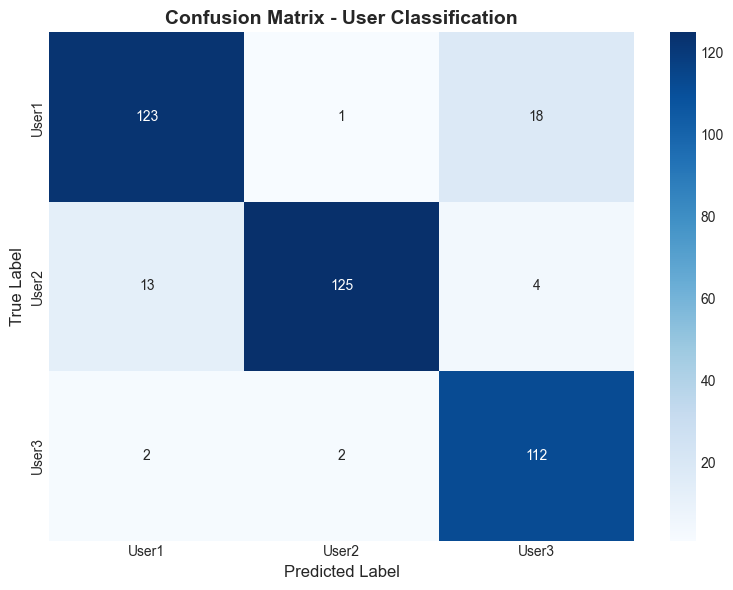


Top 10 Most Important Features:
  region_code: 0.1994
  session_duration: 0.1152
  browsing_depth: 0.1064
  scroll_activity: 0.0980
  time_on_site: 0.0656
  age: 0.0481
  content_variety: 0.0403
  interaction_count: 0.0385
  engagement_score: 0.0367
  preferred_price_range: 0.0256


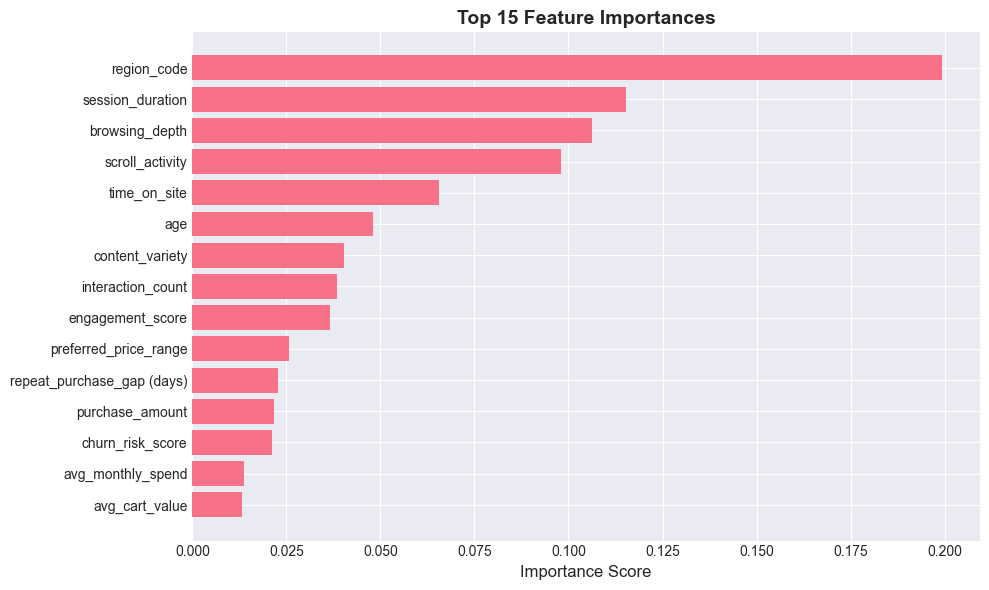


Context Mapping: {'User1': 0, 'User2': 1, 'User3': 2}


In [7]:
#Preparing features and target 
feature_cols = [col for col in train_users_clean.columns if col not in ['user_id', 'label']]
X = train_users_clean[feature_cols].copy()
y = train_users_clean['label'].copy()

#Encoding target variable
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print(f"\nFeature Engineering:")
print(f"  • Total features: {len(feature_cols)}")
print(f"  • Target classes: {le_target.classes_}")

In [29]:
#For categorical features
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
encoders = {}

X_encoded = X.copy()
X_test_final = test_users_clean[feature_cols].copy()

if len(categorical_cols) > 0:
    print(f"Encoded {len(categorical_cols)} categorical features!")
    for col in categorical_cols:
        le = LabelEncoder()
        # Combine train and test to ensure all categories are covered
        combined = pd.concat([X[col], X_test_final[col]], axis=0).astype(str)
        le.fit(combined)
        X_encoded[col] = le.transform(X[col].astype(str))
        X_test_final[col] = le.transform(X_test_final[col].astype(str))
        encoders[col] = le

Encoded 2 categorical features!


In [30]:
#Feature Scaling
scaler = StandardScaler()
numeric_features = X_encoded.select_dtypes(include=[np.number]).columns.tolist()
X_encoded[numeric_features] = scaler.fit_transform(X_encoded[numeric_features])
X_test_final[numeric_features] = scaler.transform(X_test_final[numeric_features])

# Train-Validation Split (80-20)
X_train, X_val, y_train, y_val = train_test_split(
    X_encoded, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"\nDataset Split:")
print(f"  • Training samples: {len(X_train)}")
print(f"  • Validation samples: {len(X_val)}")


Dataset Split:
  • Training samples: 1600
  • Validation samples: 400


In [31]:
# Train Random Forest Classifier!
print(f"\nTraining Random Forest Classifier...")
user_classifier = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
user_classifier.fit(X_train, y_train)

#Cross-validation for robust evaluation
cv_scores = cross_val_score(user_classifier, X_train, y_train, cv=5, scoring='accuracy')
print(f"\n5-Fold Cross-Validation Scores: {cv_scores}")
print(f"Mean CV Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

y_pred = user_classifier.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred)

#Display results
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT - Random Forest")
print("=" * 70)
print(classification_report(y_val, y_pred, target_names=le_target.classes_))
print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print("=" * 70)


Training Random Forest Classifier...

5-Fold Cross-Validation Scores: [0.89375  0.90625  0.90625  0.88125  0.834375]
Mean CV Accuracy: 0.8844 (+/- 0.0533)

CLASSIFICATION REPORT - Random Forest
              precision    recall  f1-score   support

       User1       0.89      0.87      0.88       142
       User2       0.98      0.88      0.93       142
       User3       0.84      0.97      0.90       116

    accuracy                           0.90       400
   macro avg       0.90      0.90      0.90       400
weighted avg       0.91      0.90      0.90       400


Validation Accuracy: 0.9000


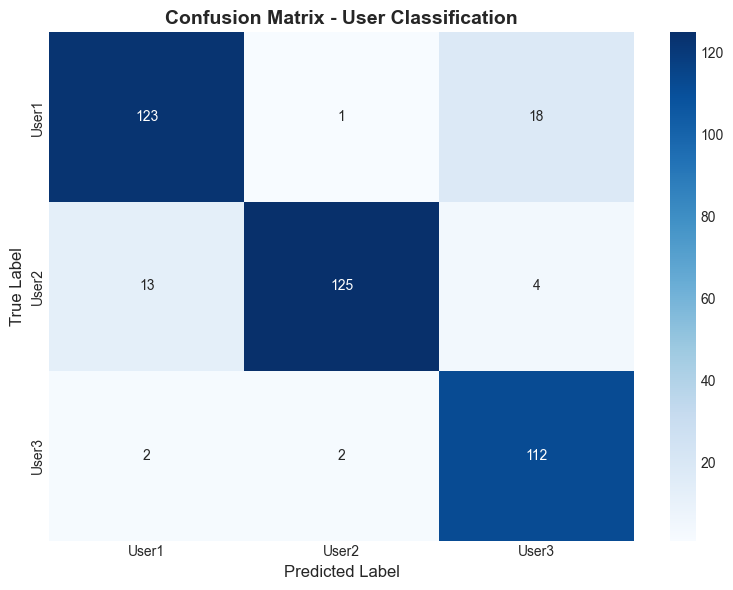

In [32]:
# Confusion Matrix Visualization
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_,
            ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix - User Classification', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
# Feature Importance Analysis
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': user_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
for idx, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")


Top 10 Most Important Features:
  region_code: 0.1994
  session_duration: 0.1152
  browsing_depth: 0.1064
  scroll_activity: 0.0980
  time_on_site: 0.0656
  age: 0.0481
  content_variety: 0.0403
  interaction_count: 0.0385
  engagement_score: 0.0367
  preferred_price_range: 0.0256


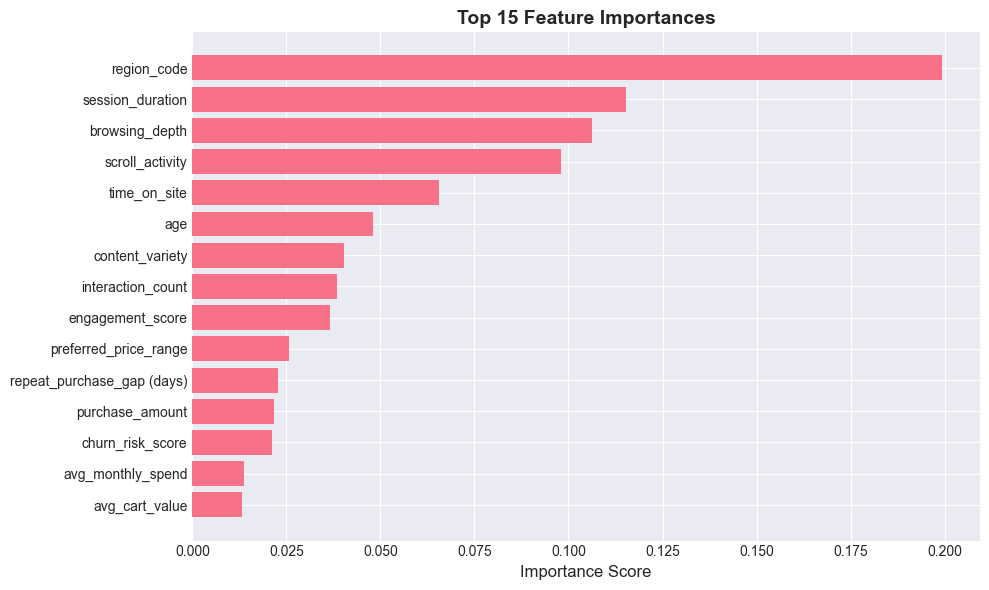

In [34]:
#Visualizing feature importance
fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(15)
ax.barh(range(len(top_features)), top_features['importance'].values)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'].values)
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 15 Feature Importances', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [35]:
#Context mapping
context_mapping = {label: idx for idx, label in enumerate(le_target.classes_)}
print(f"\nContext Mapping: {context_mapping}")


Context Mapping: {'User1': 0, 'User2': 1, 'User3': 2}


## 5.3 Contextual Bandit Algorithms

### Arm Mapping

According to the assignment, the arm index `j` maps to (News Category, User Context) combinations:

| Arm Index (j) | News Category | User Context |
|---------------|---------------|--------------|
| 0–3           | Entertainment, Education, Tech, Crime | User1 |
| 4–7           | Entertainment, Education, Tech, Crime | User2 |
| 8–11          | Entertainment, Education, Tech, Crime | User3 |

### Bandit Algorithm Implementations

### Simulation & Evaluation

Run RL simulation for T=10,000 steps and compare different hyperparameters.

### Experiment 1: Epsilon-Greedy

Test multiple values of ε and compare performance.

### Experiment 2: Upper Confidence Bound (UCB)

Test multiple values of exploration parameter C.

### Experiment 3: SoftMax

Use fixed temperature parameter τ = 1.

## 5.4 Recommendation Engine

Build an end-to-end recommendation system that:
1. Takes user features as input
2. Predicts user context (User1/User2/User3)
3. Selects optimal news category using trained bandit
4. Samples a specific article from that category